# NCBIblast service from BioServices

This example illustrate the NCBIBlast module usage within BioServices.

<i>"The emphasis of NCBIBlast is to find regions of sequence similarity, which will yield functional and evolutionary clues about the structure and function of your novel sequence." -- from NCBIblast web page.</i>

In [1]:
import matplotlib.pyplot as plt
from bioservices import UniProt, NCBIblast


<i>First, we need to get a FASTA sequence, which will be the input to the NCBIblast service. </i>

In [2]:
u = UniProt()

In [3]:
sequence = u.retrieve("P43403", "fasta")

# Sequence alignement can be performed with the blastp tool via NCBIblast service.

In [4]:
s = NCBIblast(verbose=False)

In [5]:
jobid = s.run(program="blastp", sequence=sequence, 
              stype="protein", database="uniprotkb", 
              email="test@whatever.co.uk")

In [9]:
print(s.get_result(jobid, "out")[0:1200])

BLASTP 2.16.0+


Reference: Stephen F. Altschul, Thomas L. Madden, Alejandro A.
Schaffer, Jinghui Zhang, Zheng Zhang, Webb Miller, and David J.
Lipman (1997), "Gapped BLAST and PSI-BLAST: a new generation of
protein database search programs", Nucleic Acids Res. 25:3389-3402.


Reference for composition-based statistics: Alejandro A. Schaffer,
L. Aravind, Thomas L. Madden, Sergei Shavirin, John L. Spouge, Yuri
I. Wolf, Eugene V. Koonin, and Stephen F. Altschul (2001),
"Improving the accuracy of PSI-BLAST protein database searches with
composition-based statistics and other refinements", Nucleic Acids
Res. 29:2994-3005.



Database: uniprotkb
           203,172,274 sequences; 75,747,523,712 total letters



Query= sp|P43403|ZAP70_HUMAN Tyrosine-protein kinase ZAP-70 OS=Homo sapiens
OX=9606 GN=ZAP70 PE=1 SV=1

Length=619
                                                                      Score     E
Sequences producing significant alignments:                          (Bits)  Value

SP:P

In [12]:
lines = s.get_result(jobid, "out").split("\n")

In [24]:
entries = [l for l in lines if l.startswith("TR")]

(array([ 27.,  18.,  31.,  18.,  64., 169.,   0.,   2.,   1.,   2.,   9.,
          4.,   3.,   4.,  24.,  65.,  30.,   5.,  17.,   4.]),
 array([ 869.  ,  889.45,  909.9 ,  930.35,  950.8 ,  971.25,  991.7 ,
        1012.15, 1032.6 , 1053.05, 1073.5 , 1093.95, 1114.4 , 1134.85,
        1155.3 , 1175.75, 1196.2 , 1216.65, 1237.1 , 1257.55, 1278.  ]),
 <BarContainer object of 20 artists>)

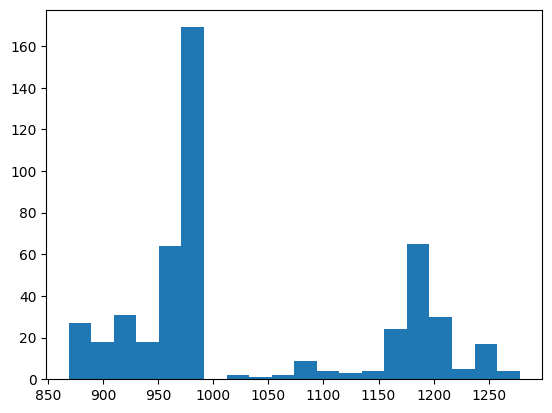

In [25]:
scores = [float(e.split()[-1]) for e in entries]
lengths = [float(e.split()[-2]) for e in entries]
from pylab import hist
hist(lengths, 20)